# Analisis Model Klasifikasi Kesegaran (Fresh vs Spoiled)

Notebook ini *tipis*: seluruh logika ada di paket `src/` (lihat `config`, `load_data`, `preprocess`, `train`, `evaluate`). Di sini kita hanya menjalankan pipeline dan menampilkan hasilnya.

Metodologi mengikuti PRD: cross-validation berbasis grup (`StratifiedGroupKFold`, 1 run = 1 grup), tanpa kebocoran data, prioritas **recall kelas `spoiled`**.

In [1]:
import sys
from pathlib import Path

# Notebook ada di notebooks/, tambahkan root proyek ke path agar `import src` jalan.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from src import config
from src.load_data import load_relabeled, class_balance, run_summary, missing_report
from src.preprocess import prepare
from src.train import tune_models, cv_score_summary, format_cv_summary
from src.evaluate import evaluate_all

pd.set_option("display.width", 120)

## 1. Data Understanding

In [2]:
df = load_relabeled()
print("Combined shape:", df.shape)
print("Jumlah run (grup):", df[config.GROUP_COLUMN].nunique())
df.head()

Combined shape: (37310, 10)
Jumlah run (grup): 14


,elapsed,mq2,mq135,mq4,humidity,tempC,food_type,label,run_id,elapsed_sec
0,02:55:27,787,640,1088,94.6,26.4,Ayam Goreng,fresh,dataset_Ayam_Goreng_20260406_082148,10527
1,02:55:57,764,624,1066,98.0,26.8,Ayam Goreng,fresh,dataset_Ayam_Goreng_20260406_082148,10557
2,02:56:27,771,618,1055,98.3,26.8,Ayam Goreng,fresh,dataset_Ayam_Goreng_20260406_082148,10587
3,02:56:57,760,623,1052,98.6,26.8,Ayam Goreng,fresh,dataset_Ayam_Goreng_20260406_082148,10617
4,02:57:27,736,594,1035,98.9,26.8,Ayam Goreng,fresh,dataset_Ayam_Goreng_20260406_082148,10647


In [3]:
print("Keseimbangan kelas per makanan:")
display(class_balance(df))
print("\nRun per makanan:")
display(run_summary(df))
print("\nMissing values (fitur numerik):")
print(missing_report(df))

Keseimbangan kelas per makanan:


label,fresh,spoiled,total
food_type,,,
Ayam Goreng,1487,7053,8540
Ikan Goreng,3428,5040,8468
Nasi Putih,1692,5668,7360
Telur Rebus,8622,4320,12942



Run per makanan:


,food_type,run_id,n_rows
0,Ayam Goreng,dataset_Ayam_Goreng_20260406_082148,1570
1,Ayam Goreng,dataset_Ayam_Goreng_20260412_104845,2304
2,Ayam Goreng,dataset_Ayam_Goreng_20260430_182011,2320
3,Ayam Goreng,dataset_Ayam_Goreng_20260513_173239,2346
4,Ikan Goreng,dataset_Ikan_Goreng_20260418_185501,2840
5,Ikan Goreng,dataset_Ikan_Goreng_20260426_183909,2844
6,Ikan Goreng,dataset_Ikan_Goreng_20260503_141923,2784
7,Nasi Putih,dataset_Nasi_Putih_20260408_121047,1850
8,Nasi Putih,dataset_Nasi_Putih_20260409_043004,1920
9,Nasi Putih,dataset_Nasi_Putih_20260410_042959,1890



Missing values (fitur numerik):
mq2         0
mq135       0
mq4         0
humidity    0
tempC       0
dtype: int64


### Trajektori sensor terhadap waktu
Konfirmasi bahwa nilai gas berubah seiring proses pembusukan (label masuk akal). `elapsed` hanya untuk visualisasi — **bukan** fitur model.

In [4]:
foods = sorted(df["food_type"].unique())
fig, axes = plt.subplots(len(foods), 1, figsize=(9, 3 * len(foods)), sharex=False)
for ax, food in zip(axes, foods):
    sub = df[df["food_type"] == food]
    for run, g in sub.groupby(config.GROUP_COLUMN):
        hours = g["elapsed_sec"] / 3600
        ax.plot(hours, g["mq135"], alpha=0.6, linewidth=0.8)
    ax.set_title(f"{food} — MQ135 vs jam (per run)")
    ax.set_xlabel("elapsed (jam)")
    ax.set_ylabel("mq135")
fig.tight_layout()
plt.show()

C:\Users\Rizqi Andhika\AppData\Local\Temp\ipykernel_62428\2888515617.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 2. Data Preparation
Warm-up trim, label encode (`fresh`=0, `spoiled`=1), pisahkan `X` / `y` / `groups`. Scaling & imputasi dilakukan di dalam pipeline tiap fold (lihat `make_preprocessor`).

In [5]:
X, y, groups = prepare(df)
print("X shape:", X.shape)
print("Fitur:", list(X.columns))
print("Positive rate (spoiled):", round(float(y.mean()), 3))

X shape: (37304, 6)
Fitur: ['mq2', 'mq135', 'mq4', 'humidity', 'tempC', 'food_type']
Positive rate (spoiled): 0.592


## 3. Modelling — tuning 4 model (GridSearchCV + StratifiedGroupKFold)
Cross-validation berbasis grup (1 run = 1 grup): tiap fold menguji run yang belum pernah dilihat → estimasi jujur, bebas leakage. Catatan: ini bagian paling lama (grid search untuk 4 model).

In [6]:
searches = tune_models(X, y, groups)
for name, search in searches.items():
    print(format_cv_summary(name, cv_score_summary(search)))
    print()

Logistic Regression  (best params: {'clf__C': 0.01})
    accuracy  : 0.737 +/- 0.057
    precision : 0.767 +/- 0.086
    recall    : 0.825 +/- 0.051
    f1        : 0.789 +/- 0.031
    roc_auc   : 0.746 +/- 0.052

Decision Tree  (best params: {'clf__max_depth': 5, 'clf__min_samples_leaf': 1})
    accuracy  : 0.724 +/- 0.028
    precision : 0.801 +/- 0.081
    recall    : 0.735 +/- 0.092
    f1        : 0.758 +/- 0.024
    roc_auc   : 0.772 +/- 0.018

KNN  (best params: {'clf__metric': 'euclidean', 'clf__n_neighbors': 21, 'clf__weights': 'uniform'})
    accuracy  : 0.718 +/- 0.045
    precision : 0.759 +/- 0.019
    recall    : 0.764 +/- 0.073
    f1        : 0.760 +/- 0.046
    roc_auc   : 0.726 +/- 0.032

Random Forest  (best params: {'clf__max_depth': 5, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 200})
    accuracy  : 0.737 +/- 0.024
    precision : 0.826 +/- 0.052
    recall    : 0.717 +/- 0.113
    f1        : 0.758 +/- 0.050
    roc_auc   : 0.801 +/- 0.020



## 4. Evaluation (out-of-fold, bebas leakage)
Menulis `results/comparison_table.csv`, confusion matrix, feature importance, dan `best_model.joblib`.

In [7]:
report, metrics_table, cv_summaries, best_name = evaluate_all(searches, X, y, groups)
print("Model terbaik:", best_name)
metrics_table.round(3)

Model terbaik: Logistic Regression


,accuracy,precision_spoiled,recall_spoiled,f1_spoiled,roc_auc
Logistic Regression,0.741,0.760,0.822,0.790,0.744
Decision Tree,0.722,0.779,0.741,0.759,0.767
KNN,0.717,0.760,0.763,0.761,0.725
Random Forest,0.738,0.812,0.726,0.767,0.782


confusion_decision_tree.png


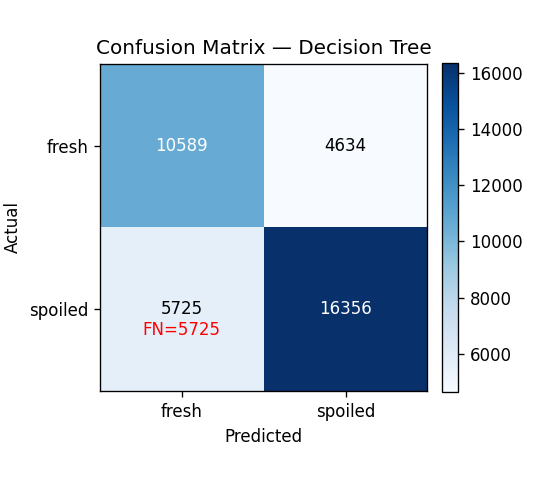

confusion_knn.png


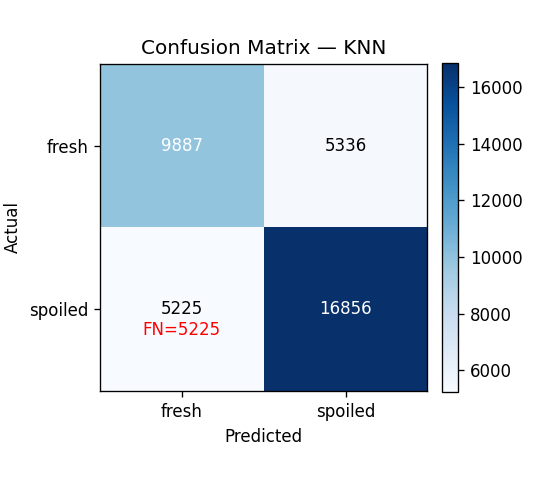

confusion_logistic_regression.png


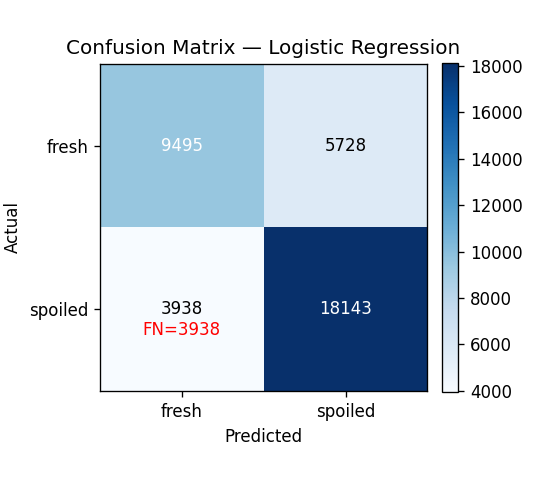

confusion_random_forest.png


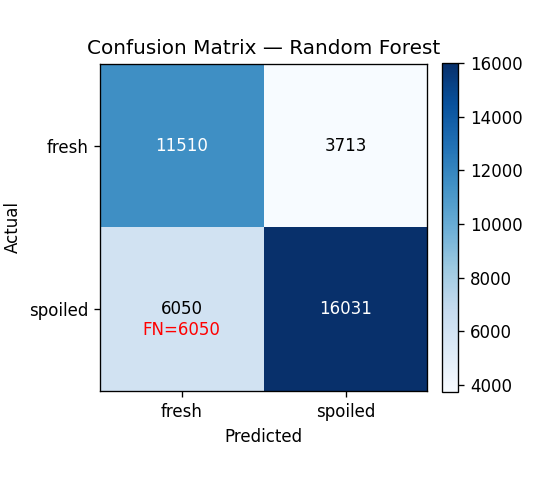

importance_per_food_mq.png


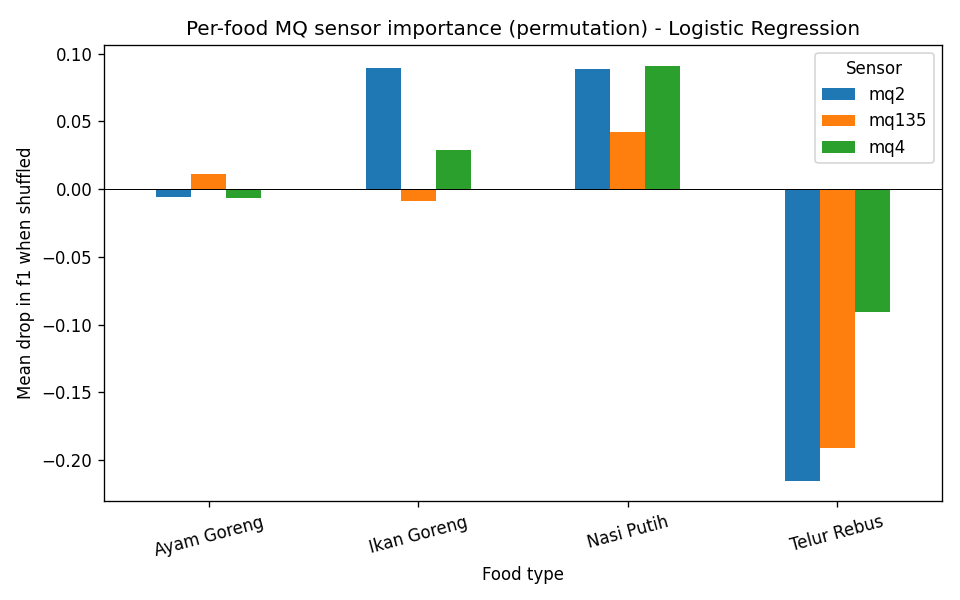

importance_per_food_mq_rf.png


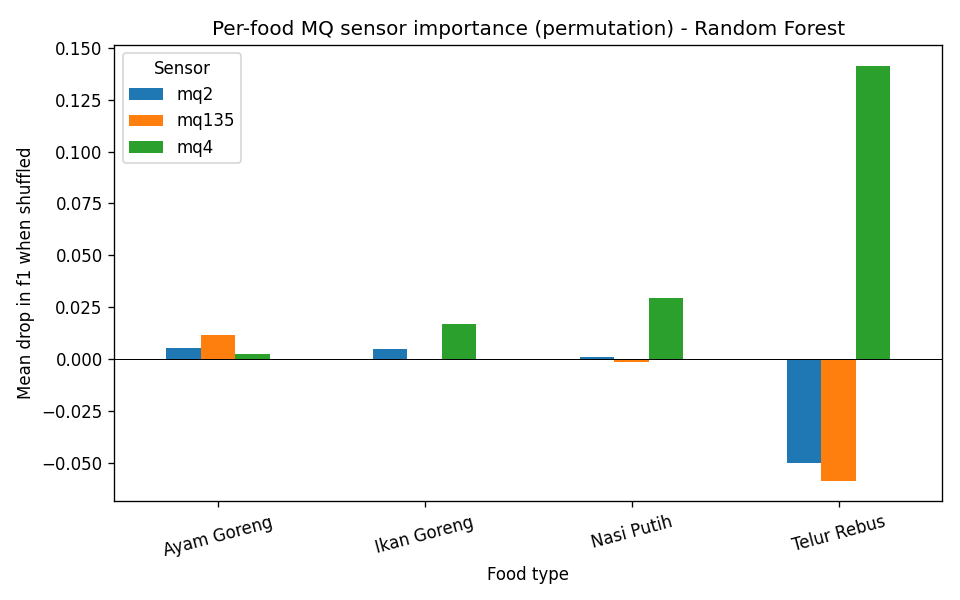

In [8]:
# Tampilkan figur yang dihasilkan (confusion matrix & feature importance)
from IPython.display import Image, display
for fig_path in sorted(config.FIGURES_DIR.glob("*.png")):
    print(fig_path.name)
    display(Image(filename=str(fig_path)))